In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!pip install -q datasets PyYAML

In [4]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK2_REPO_ROOT = (
    REPO_ROOT / "task2"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

CHECKPOINT_PATH = (
    TASK2_WORK_ROOT
    / "checkpoints/cdan_best.pt"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [5]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import yaml

import matplotlib.pyplot as plt

import pandas as pd

import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_loaders import (
    build_pacs_datasets,
    build_pacs_loaders,
)

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.backbone import (
    count_trainable_parameters,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.models.domain_discriminator import (
    DomainDiscriminator,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task2.train import (
    train_task2_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK2_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK2_REPO_ROOT
    / "configs/cdan.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    method_config = yaml.safe_load(
        config_file
    )

print(
    "Method:",
    method_config["method"]["name"],
)

print(
    "Domain-loss weight:",
    method_config["method"][
        "domain_loss_weight"
    ],
)

print(
    "Maximum GRL strength:",
    method_config["method"][
        "maximum_grl_strength"
    ],
)

print(
    "Discriminator input dimension:",
    method_config["discriminator"][
        "input_dimension"
    ],
)

print(
    "Target labels allowed:",
    base_config["selection"][
        "use_target_labels"
    ],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Method: cdan
Domain-loss weight: 1.0
Maximum GRL strength: 1.0
Discriminator input dimension: 3584
Target labels allowed: False


In [6]:
cdan_config_path = (
    TASK2_REPO_ROOT
    / "configs/cdan.yaml"
)

method_config["method"][
    "maximum_grl_strength"
] = 0.1

with cdan_config_path.open(
    "w",
    encoding="utf-8",
) as config_file:
    yaml.safe_dump(
        method_config,
        config_file,
        sort_keys=False,
    )

print(
    "Maximum GRL strength:",
    method_config["method"][
        "maximum_grl_strength"
    ],
)

print(
    "CDAN input dimension:",
    method_config["discriminator"][
        "input_dimension"
    ],
)

Maximum GRL strength: 0.1
CDAN input dimension: 3584


In [7]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

print(
    "PACS images:",
    len(pacs_dataset),
)

print(
    "Source domains:",
    pacs_protocol["source_domains"],
)

print(
    "Unlabeled target:",
    pacs_protocol["target_domain"],
)

PACS images: 9991
Source domains: ['photo', 'art_painting', 'cartoon']
Unlabeled target: sketch


In [8]:
pacs_datasets = build_pacs_datasets(
    dataset=pacs_dataset,
    protocol=pacs_protocol,
)

pacs_loaders = build_pacs_loaders(
    datasets=pacs_datasets,
    source_batch_size=8,
    target_batch_size=24,
    evaluation_batch_size=64,
    number_of_workers=2,
    seed=SEED,
)

target_sample = (
    pacs_datasets[
        "target_adaptation"
    ][0]
)

print(
    "Steps per epoch:",
    pacs_loaders["steps_per_epoch"],
)

print(
    "Source batch total:",
    8 * 3,
)

print(
    "Target batch total:",
    pacs_loaders[
        "target_adaptation"
    ].batch_size,
)

print(
    "Target label exposed:",
    "label" in target_sample,
)

Steps per epoch: 234
Source batch total: 24
Target batch total: 24
Target label exposed: False


In [9]:
set_seed(SEED)

model = PACSClassifier(
    number_of_classes=7
).to(DEVICE)

domain_discriminator = (
    DomainDiscriminator(
        input_dimension=(
            method_config[
                "discriminator"
            ]["input_dimension"]
        ),
        hidden_dimension=(
            method_config[
                "discriminator"
            ]["hidden_dimension"]
        ),
        dropout_probability=(
            method_config[
                "discriminator"
            ][
                "dropout_probability"
            ]
        ),
    ).to(DEVICE)
)

optimizer = torch.optim.AdamW(
    list(model.parameters())
    + list(
        domain_discriminator.parameters()
    ),
    lr=(
        base_config["optimization"][
            "learning_rate"
        ]
    ),
    weight_decay=(
        base_config["optimization"][
            "weight_decay"
        ]
    ),
)

selector = SourceValidationSelector(
    checkpoint_path=CHECKPOINT_PATH,
    patience=(
        base_config["optimization"][
            "early_stopping_patience"
        ]
    ),
)

print(
    "Classifier parameters:",
    count_trainable_parameters(model),
)

print(
    "Discriminator parameters:",
    count_trainable_parameters(
        domain_discriminator
    ),
)

print(
    "Discriminator input:",
    method_config["discriminator"][
        "input_dimension"
    ],
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Classifier parameters: 11180103
Discriminator parameters: 918274
Discriminator input: 3584
Checkpoint: /content/drive/MyDrive/ATML/PA1/task2/checkpoints/cdan_best.pt


In [10]:
training_result = train_task2_method(
    method_name="cdan",
    model=model,
    loaders=pacs_loaders,
    optimizer=optimizer,
    selector=selector,
    device=DEVICE,
    maximum_epochs=(
        base_config["optimization"][
            "maximum_epochs"
        ]
    ),
    domain_discriminator=(
        domain_discriminator
    ),
    method_parameters={
        "maximum_grl_strength": 0.1,
        "domain_loss_weight": 1.0,
    },
    number_of_classes=7,
)

model = training_result["model"]

domain_discriminator = (
    training_result[
        "domain_discriminator"
    ]
)

training_history = (
    training_result["history"]
)

selected_checkpoint = (
    training_result[
        "selected_checkpoint"
    ]
)

history_path = (
    TASK2_REPO_ROOT
    / "results/"
    "cdan_training_history.csv"
)

training_history.to_csv(
    history_path,
    index=False,
)

print()

print(
    "Selected epoch:",
    selected_checkpoint["epoch"],
)

print(
    "Selected mean source macro-F1:",
    selected_checkpoint[
        "selection_score"
    ],
)

print(
    "History saved to:",
    history_path,
)

cdan epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=0.6845, mean validation macro-F1=0.8419, best=0.8419


cdan epoch 2:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 2: train loss=0.6327, mean validation macro-F1=0.9232, best=0.9232


cdan epoch 3:   0%|          | 0/234 [00:00<?, ?it/s]

...

Epoch 14: train loss=0.7490, mean validation macro-F1=0.9301, best=0.9351


cdan epoch 15:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 15: train loss=0.7442, mean validation macro-F1=0.9060, best=0.9351


cdan epoch 16:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 16: train loss=0.7906, mean validation macro-F1=0.9148, best=0.9351
Early stopping triggered.

Selected epoch: 11
Selected mean source macro-F1: 0.935145377706295
History saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/results/cdan_training_history.csv


In [11]:
source_validation_results = (
    evaluate_source_domains(
        model=model,
        validation_loaders=(
            pacs_loaders[
                "source_validation"
            ]
        ),
        device=DEVICE,
        number_of_classes=7,
    )
)

source_result_rows = []

for domain_name, metrics in (
    source_validation_results[
        "domains"
    ].items()
):
    source_result_rows.append(
        {
            "method": "cdan",
            "domain": domain_name,
            "accuracy": (
                metrics["accuracy"]
            ),
            "macro_f1": (
                metrics["macro_f1"]
            ),
            "loss": metrics["loss"],
            "number_of_samples": (
                metrics[
                    "number_of_samples"
                ]
            ),
        }
    )

source_result_table = pd.DataFrame(
    source_result_rows
)

source_result_path = (
    TASK2_REPO_ROOT
    / "results/"
    "cdan_source_validation.csv"
)

source_result_table.to_csv(
    source_result_path,
    index=False,
)

print(
    source_result_table.to_string(
        index=False
    )
)

print()

print(
    "Mean source accuracy:",
    source_validation_results[
        "aggregate"
    ]["mean_accuracy"],
)

print(
    "Mean source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["mean_macro_f1"],
)

print(
    "Worst source accuracy:",
    source_validation_results[
        "aggregate"
    ]["worst_accuracy"],
)

print(
    "Worst source macro-F1:",
    source_validation_results[
        "aggregate"
    ]["worst_macro_f1"],
)

method       domain  accuracy  macro_f1     loss  number_of_samples
  cdan        photo  0.967066  0.964559 0.152821                334
  cdan art_painting  0.900000  0.900144 0.435558                410
  cdan      cartoon  0.936034  0.940733 0.244964                469

Mean source accuracy: 0.934366661134022
Mean source macro-F1: 0.935145377706295
Worst source accuracy: 0.9
Worst source macro-F1: 0.9001439382211467


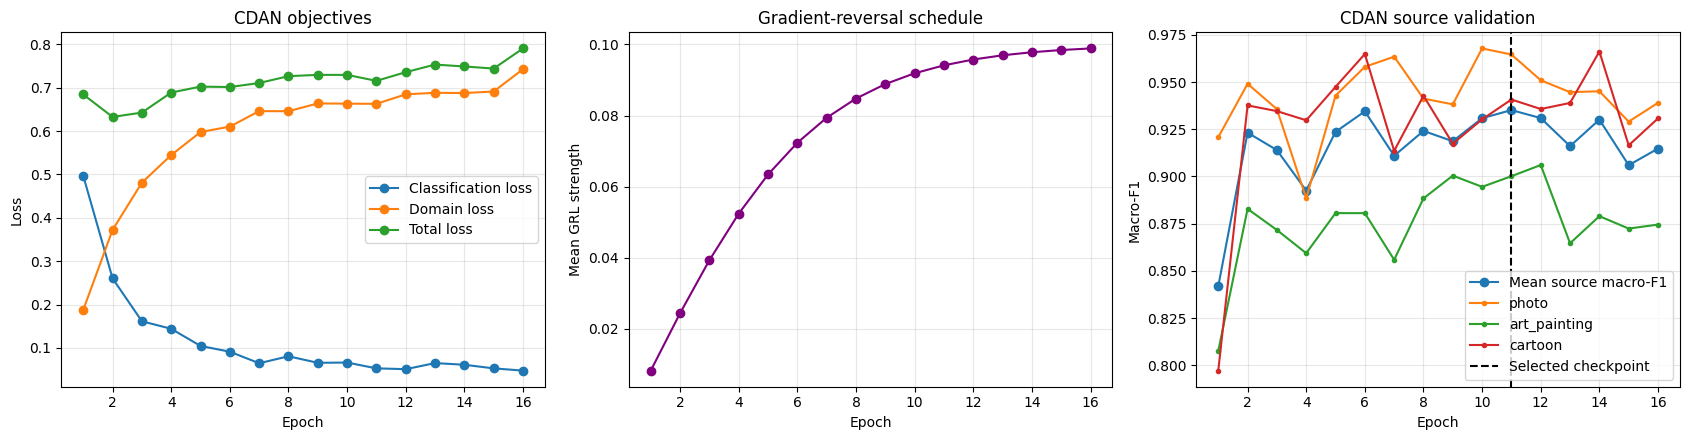

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/cdan_training_curves.png


In [13]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5),
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_classification_loss"
    ],
    marker="o",
    label="Classification loss",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_domain_loss"
    ],
    marker="o",
    label="Domain loss",
)

axes[0].plot(
    training_history["epoch"],
    training_history[
        "training_total_loss"
    ],
    marker="o",
    label="Total loss",
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CDAN objectives")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history[
        "mean_grl_strength"
    ],
    marker="o",
    color="purple",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel(
    "Mean GRL strength"
)
axes[1].set_title(
    "Gradient-reversal schedule"
)
axes[1].grid(alpha=0.3)

axes[2].plot(
    training_history["epoch"],
    training_history[
        "mean_source_validation_macro_f1"
    ],
    marker="o",
    label="Mean source macro-F1",
)

for domain_name in [
    "photo",
    "art_painting",
    "cartoon",
]:
    axes[2].plot(
        training_history["epoch"],
        training_history[
            f"{domain_name}_validation_macro_f1"
        ],
        marker=".",
        label=domain_name,
    )

axes[2].axvline(
    selected_checkpoint["epoch"],
    color="black",
    linestyle="--",
    label="Selected checkpoint",
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro-F1")
axes[2].set_title(
    "CDAN source validation"
)
axes[2].grid(alpha=0.3)
axes[2].legend()

figure.tight_layout()

figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "cdan_training_curves.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [14]:
cdan_metadata = {
    "method": "cdan",
    "seed": SEED,
    "domain_loss_weight": 1.0,
    "maximum_grl_strength": 0.1,
    "gradient_clip_norm": 1.0,
    "feature_dimension": 512,
    "number_of_classes": 7,
    "conditional_dimension": 3584,
    "selected_epoch": int(
        selected_checkpoint["epoch"]
    ),
    "selection_metric": (
        selected_checkpoint[
            "selection_metric"
        ]
    ),
    "selection_score": float(
        selected_checkpoint[
            "selection_score"
        ]
    ),
    "checkpoint_filename": (
        CHECKPOINT_PATH.name
    ),
    "target_images_used_during_training": True,
    "target_labels_used": False,
    "source_validation": {
        domain_name: {
            "accuracy": float(
                metrics["accuracy"]
            ),
            "macro_f1": float(
                metrics["macro_f1"]
            ),
            "loss": float(
                metrics["loss"]
            ),
            "number_of_samples": int(
                metrics[
                    "number_of_samples"
                ]
            ),
        }
        for domain_name, metrics
        in source_validation_results[
            "domains"
        ].items()
    },
    "aggregate_source_validation": {
        key: float(value)
        for key, value
        in source_validation_results[
            "aggregate"
        ].items()
    },
}

metadata_path = (
    TASK2_REPO_ROOT
    / "results/cdan_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        cdan_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        cdan_metadata,
        indent=2,
    )
)

{
  "method": "cdan",
  "seed": 6304,
  "domain_loss_weight": 1.0,
  "maximum_grl_strength": 0.1,
  "gradient_clip_norm": 1.0,
  "feature_dimension": 512,
  "number_of_classes": 7,
  "conditional_dimension": 3584,
  "selected_epoch": 11,
  "selection_metric": "mean_source_validation_macro_f1",
  "selection_score": 0.935145377706295,
  "checkpoint_filename": "cdan_best.pt",
  "target_images_used_during_training": true,
  "target_labels_used": false,
  "source_validation": {
    "photo": {
      "accuracy": 0.9670658682634731,
      "macro_f1": 0.9645593559247339,
      "loss": 0.152821320705785,
      "number_of_samples": 334
    },
    "art_painting": {
      "accuracy": 0.9,
      "macro_f1": 0.9001439382211467,
      "loss": 0.4355581530710546,
      "number_of_samples": 410
    },
    "cartoon": {
      "accuracy": 0.9360341151385928,
      "macro_f1": 0.9407328389730046,
      "loss": 0.2449639753492148,
      "number_of_samples": 469
    }
  },
  "aggregate_source_validation": {
 